# DQN Learning Dynamics in the Prisoner's Dilemma

This notebook tests the hypothesis:
**"DQN without replay buffer shows similar complex dynamics to tabular Q-learning"**

We compare the learning dynamics of two DQN agents playing the Prisoner's Dilemma
against the tabular Q-learning baseline from the main paper.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Import from local agent_game_sim.py (includes DQNAgent)
from agent_game_sim import (
    Game, 
    Simulation, 
    QLearningAgent,
    DQNAgent,
    reward_matrix_for_two_player_PD,
    generate_q_values
)

# Set random seeds for reproducibility
SEED = 13
np.random.seed(SEED)
import torch
torch.manual_seed(SEED)

print("Setup complete!")
print(f"PyTorch version: {torch.__version__}")

Setup complete!
PyTorch version: 2.10.0


## Experiment Parameters

In [2]:
# Parameters matching the paper
num_players = 2
action_space = np.array([0, 1])  # 0 = cooperate, 1 = defect
observation_length = 0  # Stateless

# Learning parameters
learning_rate = 0.01
temperature = 1.0
base_value = 0

# Initial cooperation probabilities
initial_probability_pair = (0.5, 0.48)

# Discount factors to test
discount_factors = [0.0, 0.8]

# Number of time steps
num_time_steps_short = 3000  # For gamma=0 (converges quickly)
num_time_steps_long = int(2e5)  # For gamma=0.8 (slower dynamics)

print(f"Initial probabilities: {initial_probability_pair}")
print(f"Learning rate: {learning_rate}")
print(f"Temperature: {temperature}")

Initial probabilities: (0.5, 0.48)
Learning rate: 0.01
Temperature: 1.0


## Helper Functions

In [3]:
def run_dqn_experiment(discount_factor, initial_probs, num_time_steps, seed=42):
    """
    Run a DQN experiment with two agents playing Prisoner's Dilemma.
    
    Returns:
        dict with cooperation probability histories for both agents
    """
    # Set seeds
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Create DQN agents
    agents = [
        DQNAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            reward_func=reward_matrix_for_two_player_PD,
            learning_rate=learning_rate,
            discount_factor=discount_factor,
            temperature=temperature,
            initial_prob=initial_probs[i],
            base_value=base_value,
            use_prefactor=False  # Match paper configuration
        )
        for i in range(num_players)
    ]
    
    # Run simulation using existing infrastructure
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    # Extract cooperation probabilities from Q-table history
    prob_histories = []
    for agent in agents:
        # Get cooperation probability at each timestep
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents,
        'params': {
            'discount_factor': discount_factor,
            'initial_probs': initial_probs,
            'num_time_steps': num_time_steps
        }
    }


def run_dqn_replay_experiment(discount_factor, initial_probs, num_time_steps,
                               buffer_size=10000, min_buffer_size=100, 
                               batch_size=32, seed=42):
    """
    Run a DQN experiment WITH replay buffer (standard DQN).
    Samples batch_size experiences from buffer and averages loss over the batch.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    agents = [
        DQNAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            reward_func=reward_matrix_for_two_player_PD,
            learning_rate=learning_rate,
            discount_factor=discount_factor,
            temperature=temperature,
            initial_prob=initial_probs[i],
            base_value=base_value,
            use_prefactor=False,
            use_replay_buffer=True,
            buffer_size=buffer_size,
            min_buffer_size=min_buffer_size,
            batch_size=batch_size
        )
        for i in range(num_players)
    ]
    
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    prob_histories = []
    for agent in agents:
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents
    }


def run_tabular_experiment(discount_factor, initial_probs, num_time_steps, seed=42):
    """
    Run a tabular Q-learning experiment for comparison.
    """
    np.random.seed(seed)
    
    # Create initial Q-tables from probabilities
    initial_q_tables = [
        np.expand_dims(generate_q_values(prob, temperature, base_value), axis=0)
        for prob in initial_probs
    ]
    
    # Create tabular agents
    agents = [
        QLearningAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            discount_factor=discount_factor,
            observation_length=observation_length,
            selection_method="Boltzmann",
            reward_func=reward_matrix_for_two_player_PD,
            temperature=temperature,
            learning_rate=learning_rate,
            q_table=initial_q_tables[i],
            use_prefactor=False  # Match paper configuration
        )
        for i in range(num_players)
    ]
    
    # Run simulation
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    # Extract cooperation probabilities
    prob_histories = []
    for agent in agents:
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents
    }


def plot_comparison(dqn_results, tabular_results, title, save_path=None):
    """
    Plot DQN vs tabular cooperation probabilities.
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    colors = ['C0', 'C1']
    
    for i, ax in enumerate(axes):
        # Plot tabular (dashed)
        ax.plot(tabular_results[f'prob_agent_{i}'], 
                color=colors[i], linestyle='--', alpha=0.7, 
                label=f'Tabular Agent {i+1}', linewidth=1.5)
        
        # Plot DQN (solid)
        ax.plot(dqn_results[f'prob_agent_{i}'], 
                color=colors[i], linestyle='-', alpha=0.9,
                label=f'DQN Agent {i+1}', linewidth=1.5)
        
        ax.set_ylabel(f'Agent {i+1}\n$\\pi^{i+1}_C$', fontsize=11)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    
    # Format x-axis
    def formatter(x, pos):
        return f'{x/1e3:.0f}'
    axes[-1].xaxis.set_major_formatter(FuncFormatter(formatter))
    axes[-1].set_xlabel('Time step $t$ [×$10^3$]', fontsize=11)
    
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()


def plot_three_way_comparison(tabular_results, dqn_results, dqn_replay_results, title, save_path=None):
    """
    Plot tabular vs DQN vs DQN+replay cooperation probabilities.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    
    for i, ax in enumerate(axes):
        # Plot tabular (dashed)
        ax.plot(tabular_results[f'prob_agent_{i}'], 
                color='C0', linestyle='--', alpha=0.7, 
                label='Tabular Q-learning', linewidth=1.5)
        
        # Plot DQN no replay (solid)
        ax.plot(dqn_results[f'prob_agent_{i}'], 
                color='C1', linestyle='-', alpha=0.9,
                label='DQN (no replay)', linewidth=1.5)
        
        # Plot DQN with replay (dotted)
        ax.plot(dqn_replay_results[f'prob_agent_{i}'], 
                color='C2', linestyle=':', alpha=0.9,
                label='DQN (with replay)', linewidth=2)
        
        ax.set_ylabel(f'Agent {i+1}\n$\\pi^{i+1}_C$', fontsize=11)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    
    # Format x-axis
    def formatter(x, pos):
        return f'{x/1e3:.0f}'
    axes[-1].xaxis.set_major_formatter(FuncFormatter(formatter))
    axes[-1].set_xlabel('Time step $t$ [×$10^3$]', fontsize=11)
    
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()


print("Helper functions defined.")

Helper functions defined.


## Experiment 1: γ = 0 (No Discounting)

With γ=0, both tabular and DQN should converge to mutual defection relatively quickly.

In [4]:
print("Running experiments with γ = 0...")
print(f"Time steps: {num_time_steps_short}")

# Run DQN experiment
print("\nRunning DQN...")
dqn_results_g0 = run_dqn_experiment(
    discount_factor=0.0,
    initial_probs=initial_probability_pair,
    num_time_steps=num_time_steps_short
)
print(f"DQN final cooperation probs: ({dqn_results_g0['prob_agent_0'][-1]:.4f}, {dqn_results_g0['prob_agent_1'][-1]:.4f})")

# Run tabular experiment
print("\nRunning Tabular Q-learning...")
tabular_results_g0 = run_tabular_experiment(
    discount_factor=0.0,
    initial_probs=initial_probability_pair,
    num_time_steps=num_time_steps_short
)
print(f"Tabular final cooperation probs: ({tabular_results_g0['prob_agent_0'][-1]:.4f}, {tabular_results_g0['prob_agent_1'][-1]:.4f})")

Running experiments with γ = 0...
Time steps: 3000

Running DQN...
DQN final cooperation probs: (0.2565, 0.2339)

Running Tabular Q-learning...
Tabular final cooperation probs: (0.2494, 0.2184)


Saved to figures/comparison_gamma_0.png


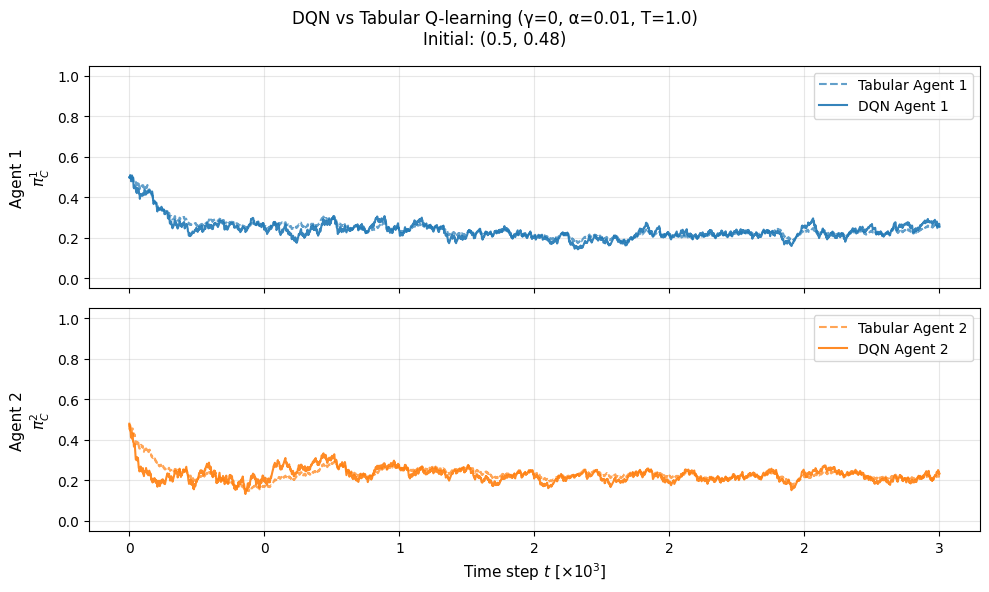

In [5]:
# Plot comparison for γ = 0
plot_comparison(
    dqn_results_g0, 
    tabular_results_g0,
    title=f"DQN vs Tabular Q-learning (γ=0, α={learning_rate}, T={temperature})\n"
          f"Initial: {initial_probability_pair}",
    save_path='figures/comparison_gamma_0.png'
)

## Experiment 2: γ = 0.8 (With Discounting)

With γ=0.8, we expect to see the complex dynamics: transient cooperation, metastability, and slower convergence.

In [6]:
print("Running experiments with γ = 0.8...")
print(f"Time steps: {num_time_steps_long}")

# Run DQN experiment
print("\nRunning DQN...")
dqn_results_g8 = run_dqn_experiment(
    discount_factor=0.8,
    initial_probs=initial_probability_pair,
    num_time_steps=num_time_steps_long
)
print(f"DQN final cooperation probs: ({dqn_results_g8['prob_agent_0'][-1]:.4f}, {dqn_results_g8['prob_agent_1'][-1]:.4f})")

# Run tabular experiment
print("\nRunning Tabular Q-learning...")
tabular_results_g8 = run_tabular_experiment(
    discount_factor=0.8,
    initial_probs=initial_probability_pair,
    num_time_steps=num_time_steps_long
)
print(f"Tabular final cooperation probs: ({tabular_results_g8['prob_agent_0'][-1]:.4f}, {tabular_results_g8['prob_agent_1'][-1]:.4f})")

Running experiments with γ = 0.8...
Time steps: 200000

Running DQN...
DQN final cooperation probs: (0.0191, 0.3339)

Running Tabular Q-learning...
Tabular final cooperation probs: (0.1217, 0.1959)


Saved to figures/comparison_gamma_0.8.png


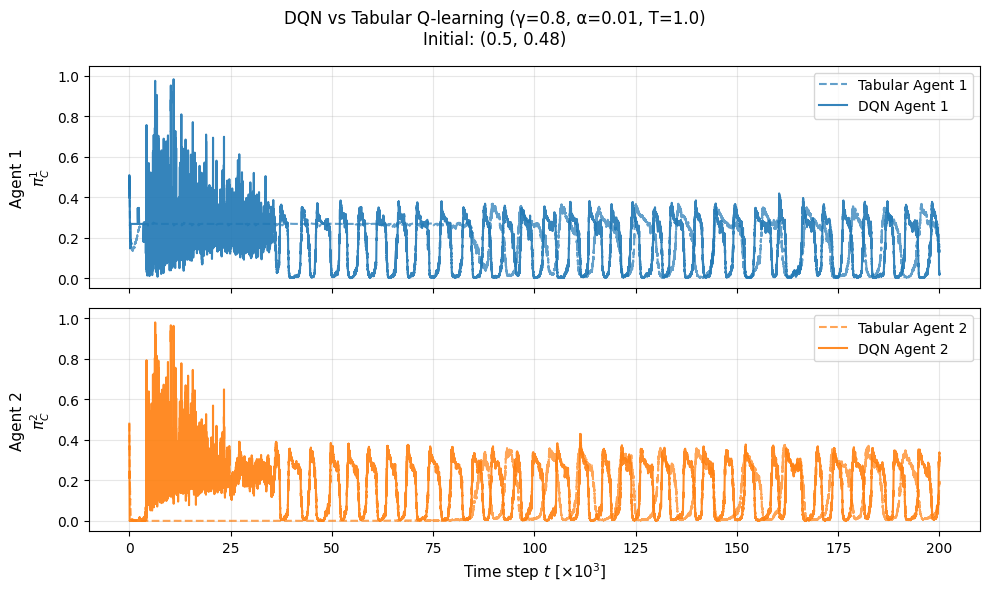

In [7]:
# Plot comparison for γ = 0.8
plot_comparison(
    dqn_results_g8, 
    tabular_results_g8,
    title=f"DQN vs Tabular Q-learning (γ=0.8, α={learning_rate}, T={temperature})\n"
          f"Initial: {initial_probability_pair}",
    save_path='figures/comparison_gamma_0.8.png'
)

## Analysis: Q-Value Evolution

Let's also compare how the Q-values evolve over time.

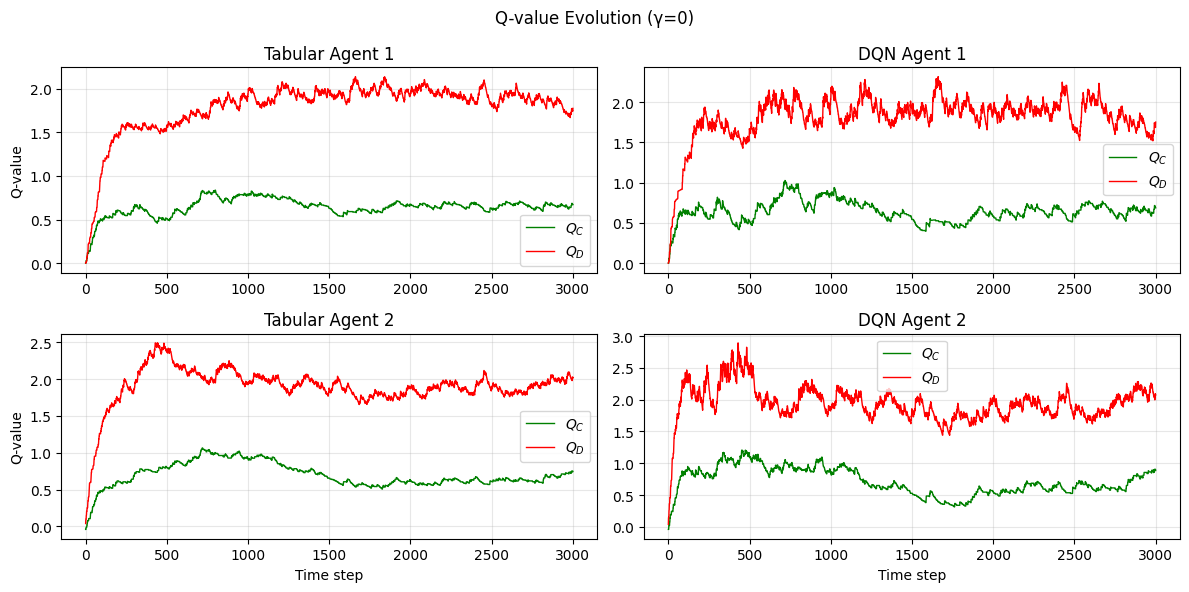

In [8]:
def plot_q_values(dqn_results, tabular_results, title, max_steps=None):
    """
    Plot Q-value evolution for both agents.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    
    colors = ['C0', 'C1']
    
    for i in range(2):  # For each agent
        # Get Q-values
        dqn_q = np.array([q[0] for q in dqn_results['agents'][i].q_table_history])
        tab_q = np.array([q[0] for q in tabular_results['agents'][i].q_table_history])
        
        if max_steps:
            dqn_q = dqn_q[:max_steps]
            tab_q = tab_q[:max_steps]
        
        # Tabular Q-values
        axes[i, 0].plot(tab_q[:, 0], label='$Q_C$', color='green', linewidth=1)
        axes[i, 0].plot(tab_q[:, 1], label='$Q_D$', color='red', linewidth=1)
        axes[i, 0].set_title(f'Tabular Agent {i+1}')
        axes[i, 0].set_ylabel('Q-value')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        
        # DQN Q-values
        axes[i, 1].plot(dqn_q[:, 0], label='$Q_C$', color='green', linewidth=1)
        axes[i, 1].plot(dqn_q[:, 1], label='$Q_D$', color='red', linewidth=1)
        axes[i, 1].set_title(f'DQN Agent {i+1}')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
    
    axes[-1, 0].set_xlabel('Time step')
    axes[-1, 1].set_xlabel('Time step')
    
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# Plot Q-values for γ = 0
plot_q_values(
    dqn_results_g0, 
    tabular_results_g0,
    title="Q-value Evolution (γ=0)"
)

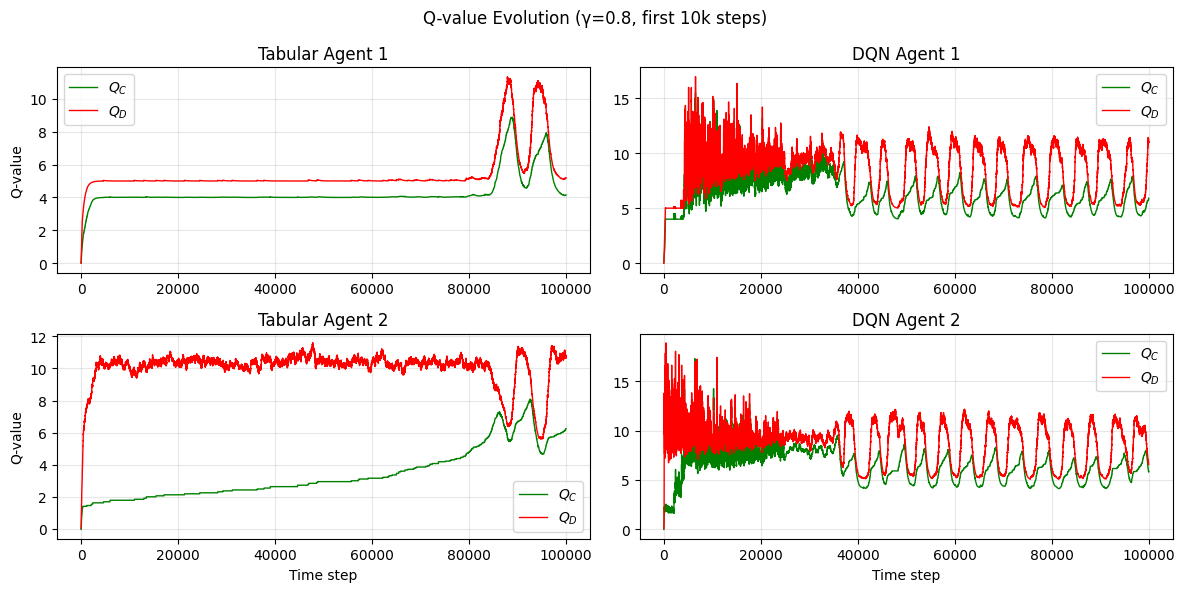

In [9]:
# Plot Q-values for γ = 0.8 (first 10k steps for clarity)
plot_q_values(
    dqn_results_g8, 
    tabular_results_g8,
    title="Q-value Evolution (γ=0.8, first 10k steps)",
    max_steps=100000
)

## Experiment 3: Replay Buffer Effect

Test hypothesis: **"Does breaking the tight feedback loop (via replay buffer) dampen the complex dynamics?"**

In [11]:
print("Running DQN with replay buffer (γ = 0.8)...")

# DQN with replay buffer (standard DQN: batch_size=32)
print("\n1. Standard DQN (batch_size=32, buffer_size=100)...")
dqn_replay_results_g8 = run_dqn_replay_experiment(
    discount_factor=0.8,
    initial_probs=initial_probability_pair,
    num_time_steps=num_time_steps_long,
    buffer_size=100,
    min_buffer_size=100,
    batch_size=32
)
print(f"   Final cooperation probs: ({dqn_replay_results_g8['prob_agent_0'][-1]:.4f}, {dqn_replay_results_g8['prob_agent_1'][-1]:.4f})")

# DQN with replay buffer=1, batch_size=1 (equivalent to no replay)
print("\n2. DQN replay sanity check (batch_size=1, buffer_size=1, min_buffer_size=1)...")
dqn_replay_trivial_g8 = run_dqn_replay_experiment(
    discount_factor=0.8,
    initial_probs=initial_probability_pair,
    num_time_steps=num_time_steps_long,
    buffer_size=1,
    min_buffer_size=1,
    batch_size=1
)
print(f"   Final cooperation probs: ({dqn_replay_trivial_g8['prob_agent_0'][-1]:.4f}, {dqn_replay_trivial_g8['prob_agent_1'][-1]:.4f})")

Running DQN with replay buffer (γ = 0.8)...

1. Standard DQN (batch_size=32, buffer_size=10000)...
   Final cooperation probs: (0.1689, 0.2028)

2. DQN replay sanity check (batch_size=1, buffer_size=1, min_buffer_size=1)...
   Final cooperation probs: (0.0191, 0.3339)


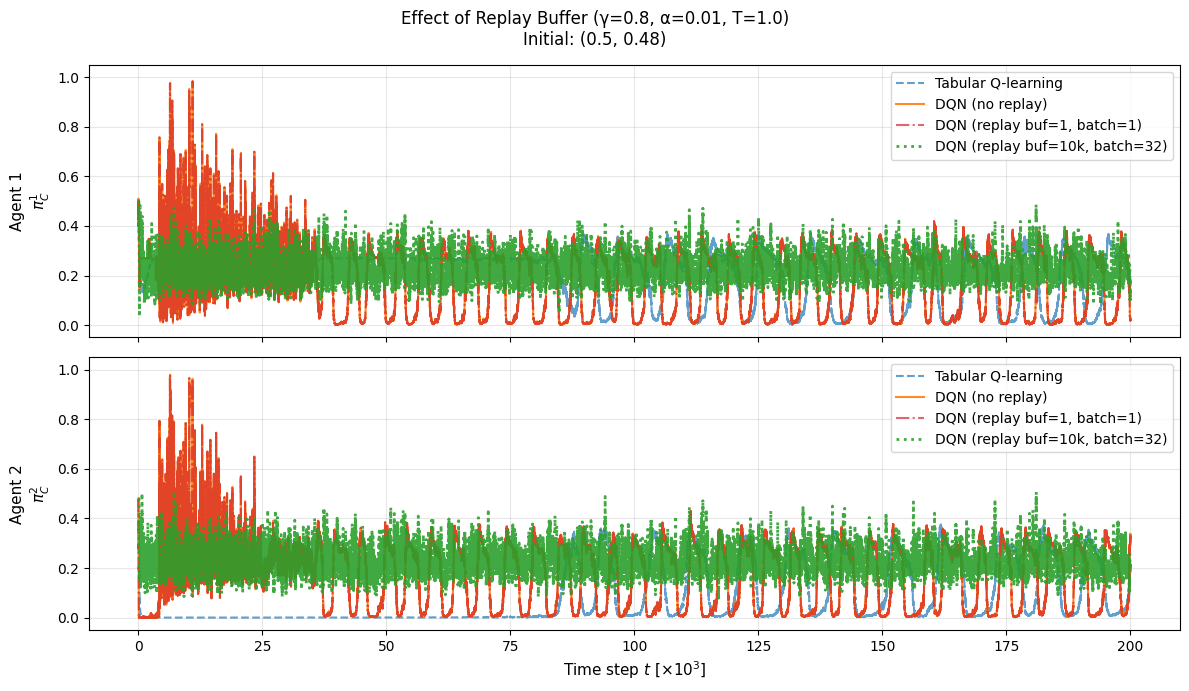

In [ ]:
# Four-way comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(tabular_results_g8[f'prob_agent_{i}'], 
            color='C0', linestyle='--', alpha=0.7, 
            label='Tabular Q-learning', linewidth=1.5)
    
    ax.plot(dqn_results_g8[f'prob_agent_{i}'], 
            color='C1', linestyle='-', alpha=0.9,
            label='DQN (no replay)', linewidth=1.5)
    
    ax.plot(dqn_replay_trivial_g8[f'prob_agent_{i}'], 
            color='C3', linestyle='-.', alpha=0.7,
            label='DQN (replay buf=1, batch=1)', linewidth=1.5)
    
    ax.plot(dqn_replay_results_g8[f'prob_agent_{i}'], 
            color='C2', linestyle=':', alpha=0.9,
            label='DQN (replay buf=100, batch=32)', linewidth=2)
    
    ax.set_ylabel(f'Agent {i+1}\n$\\pi^{i+1}_C$', fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

def formatter(x, pos):
    return f'{x/1e3:.0f}'
axes[-1].xaxis.set_major_formatter(FuncFormatter(formatter))
axes[-1].set_xlabel('Time step $t$ [×$10^3$]', fontsize=11)

fig.suptitle(f"Effect of Replay Buffer (γ=0.8, α={learning_rate}, T={temperature})\n"
             f"Initial: {initial_probability_pair}", fontsize=12)
plt.tight_layout()
plt.savefig('figures/replay_buffer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Compute average cooperation probabilities over different time periods
def compute_period_averages(results, periods):
    """Compute average cooperation probability for each agent over specified periods."""
    averages = {}
    for start, end in periods:
        period_key = f"{start//1000}k-{end//1000}k"
        avg_0 = np.mean(results['prob_agent_0'][start:end])
        avg_1 = np.mean(results['prob_agent_1'][start:end])
        averages[period_key] = (avg_0, avg_1)
    return averages

# Define time periods
min_t = int(1e5)
max_t = num_time_steps_long
periods = [(min_t, max_t)]

# Compute averages for each method
all_results = {
    'Tabular': tabular_results_g8,
    'DQN (no replay)': dqn_results_g8,
    'DQN (buf=1, b=1)': dqn_replay_trivial_g8,
    'DQN (buf=10k, b=32)': dqn_replay_results_g8,
}

print("Average Cooperation Probabilities (γ=0.8)")
print("=" * 85)
print(f"{'Method':<25} {'Period Avg (Agent1, Agent2)':<30} {'Overall Avg':<20} {'Variance':<15}")
print("-" * 85)

for name, results in all_results.items():
    avgs = compute_period_averages(results, periods)
    period_key = list(avgs.keys())[0]
    a0, a1 = avgs[period_key]
    overall_0 = np.mean(results['prob_agent_0'])
    overall_1 = np.mean(results['prob_agent_1'])
    var_0 = np.var(results['prob_agent_0'])
    var_1 = np.var(results['prob_agent_1'])
    print(f"{name:<25} ({a0:.3f}, {a1:.3f})                ({overall_0:.3f}, {overall_1:.3f})      ({var_0:.4f}, {var_1:.4f})")

print("-" * 85)

## Save Results

In [ ]:
if False:  # Set to True to save Q-value plots
    import os
    # Create data directory
    os.makedirs('../data/DQN', exist_ok=True)
    os.makedirs('figures', exist_ok=True)

    # Save DQN results
    for gamma, results in [(0.0, dqn_results_g0), (0.8, dqn_results_g8)]:
        probs = np.array([results['prob_agent_0'], results['prob_agent_1']])
        filename = f"../data/DQN/probabilities_DQN_gamma_{gamma}_alpha_{learning_rate}_T_{temperature}.npy"
        np.save(filename, probs)
        print(f"Saved: {filename}")

    print("\nDone!")

: 

## Summary

### Key Observations:

1. **γ = 0**: Both DQN and tabular converge to mutual defection. 
   - The dynamics should be qualitatively similar
   - DQN may show slightly different trajectories due to gradient coupling

2. **γ = 0.8**: This is where we expect to see complex dynamics.
   - **If DQN shows similar oscillations/metastability**: Supports hypothesis that incremental updates are key
   - **If DQN dynamics differ significantly**: Suggests neural network parameterization affects dynamics

### Next Steps:
- Add replay buffer to DQN and compare (expect dynamics to be damped)
- Try different initial conditions
- Implement PPO for comparison